# GLMsingle beta-version QC — decoding comparison

Aggregates the per-subject CSVs written by `run_beta_qc_decoding.py` and asks a
single question: **does GLMsingle's denoising/ridge pipeline (B→C→D) improve
decodability on this dataset?**

- **A** = ONOFF, **B** = +FITHRF, **C** = +GLMDENOISE, **D** = +ridge (fracridge).
  **A is written but excluded from decoding** — ONOFF pools every event into one
  on/off beta per voxel, so there's no per-trial dimension to decode. The real
  comparison is **B → C → D**.
- Decoding target: **stimulus category** (LinearSVC, accuracy, chance 0.25), same
  standardized decoder / LOGO-CV on every beta version, run on **both** a
  whole-brain mask and a visual-cortex ROI (Harvard-Oxford occipital+fusiform,
  same mask `run_decoding.py` uses). The ROI is the more diagnostic of the two —
  whole-brain dilutes the category signal with tens of thousands of non-visual
  voxels, which can swamp subtler beta-version differences given only 328 trials.
  Category decoding is a **pipeline-validation probe**, not a result of interest;
  the analyses of interest (reward/value) live in `run_qvalue_*.py`.

B→D is usually but **not guaranteed** monotonic; a dip is informative (e.g. GLMdenoise
removing condition-correlated variance), not a bug.

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory holding the per-subject sub-*/sub-*_beta_qc_decoding.csv files
# (the --output-dir passed to run_beta_qc_decoding.py). Edit for your filesystem.
QC_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/glmsingle_qc")

# Type A (ONOFF) is never in the data -- run_beta_qc_decoding.py skips it (no
# per-trial betas to decode). Only B/C/D are ever written.
BETA_ORDER = ["B", "C", "D"]
BETA_LABELS = {"B": "B\n+FITHRF", "C": "C\n+GLMdenoise", "D": "D\n+ridge"}

In [2]:
# Load and concatenate all per-subject QC CSVs
csvs = sorted(glob.glob(str(QC_DIR / "sub-*" / "sub-*_beta_qc_decoding.csv")))
assert csvs, f"No beta-QC CSVs found under {QC_DIR}"
df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
df["beta_type"] = pd.Categorical(df["beta_type"], categories=BETA_ORDER, ordered=True)

n_sub = df["subject"].nunique()
print(f"{len(csvs)} subjects, targets: {sorted(df['target'].unique())}")
df.head()

59 subjects, targets: ['category']


,subject,beta_type,mask,target,metric,value,baseline
0,sub-01,B,wholebrain,category,accuracy,0.353659,0.25
1,sub-01,B,visualcortex,category,accuracy,0.530488,0.25
2,sub-01,C,wholebrain,category,accuracy,0.347561,0.25
3,sub-01,C,visualcortex,category,accuracy,0.536585,0.25
4,sub-01,D,wholebrain,category,accuracy,0.338415,0.25


In [3]:
# Group summary: mean ± sem per beta_type x mask, plus mean gain relative to type-B
# (type A is excluded from decoding — see intro cell — so B is the comparison baseline)
summary = (df.groupby(["mask", "beta_type"], observed=True)["value"]
             .agg(mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(x.count()), n="count")
             .reset_index())

for msk in ["wholebrain", "visualcortex"]:
    s = summary[summary["mask"] == msk].set_index("beta_type")
    base = s.loc["B", "mean"] if "B" in s.index else np.nan
    print(f"\n=== {msk} (accuracy) ===")
    for bt in BETA_ORDER:
        if bt in s.index:
            m, se = s.loc[bt, "mean"], s.loc[bt, "sem"]
            print(f"  {bt}: {m:.3f} ± {se:.3f}   (Δ vs B: {m - base:+.3f})")
summary


=== wholebrain (accuracy) ===
  B: 0.357 ± 0.007   (Δ vs B: +0.000)
  C: 0.372 ± 0.008   (Δ vs B: +0.016)
  D: 0.368 ± 0.008   (Δ vs B: +0.011)

=== visualcortex (accuracy) ===
  B: 0.468 ± 0.013   (Δ vs B: +0.000)
  C: 0.482 ± 0.012   (Δ vs B: +0.014)
  D: 0.483 ± 0.013   (Δ vs B: +0.015)


,mask,beta_type,mean,sem,n
0,visualcortex,B,0.468220,0.013150,59
1,visualcortex,C,0.482224,0.012446,59
2,visualcortex,D,0.483309,0.012533,59
3,wholebrain,B,0.356656,0.007497,59
4,wholebrain,C,0.372313,0.008087,59
5,wholebrain,D,0.368024,0.008386,59


In [4]:
# Paired significance tests, per mask: does GLMdenoise (C) beat FITHRF (B),
# and does ridge (D) beat GLMdenoise (C)? Subject-paired (n=59). Both a
# parametric paired t-test and the non-parametric Wilcoxon signed-rank test,
# since with only 3 ordered conditions there's no reason to lean on a
# normality assumption we haven't checked.
from scipy import stats

PAIRS = [("B", "C"), ("C", "D"), ("B", "D")]

rows = []
for msk in ["wholebrain", "visualcortex"]:
    wide = (df[df["mask"] == msk]
            .pivot_table(index="subject", columns="beta_type", values="value", observed=True)
            .reindex(columns=BETA_ORDER))
    for a, b in PAIRS:
        diff = wide[b] - wide[a]
        t, p_t = stats.ttest_rel(wide[b], wide[a])
        try:
            _, p_w = stats.wilcoxon(wide[b], wide[a])
        except ValueError:
            p_w = np.nan  # degenerate: all differences are zero
        rows.append({"mask": msk, "pair": f"{a}→{b}", "mean_diff": diff.mean(),
                     "t": t, "p_ttest": p_t, "p_wilcoxon": p_w})

stats_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
stats_df

,mask,pair,mean_diff,t,p_ttest,p_wilcoxon
0,wholebrain,B→C,0.0157,4.0337,0.0002,0.0002
1,wholebrain,C→D,-0.0043,-1.7371,0.0877,0.0742
2,wholebrain,B→D,0.0114,2.6858,0.0094,0.0055
3,visualcortex,B→C,0.0140,3.9564,0.0002,0.0002
4,visualcortex,C→D,0.0011,0.3921,0.6964,0.4409
5,visualcortex,B→D,0.0151,4.1440,0.0001,0.0003


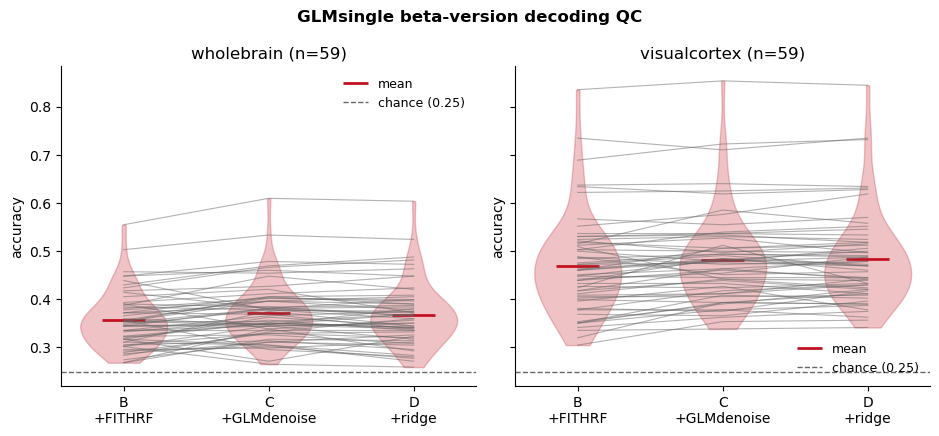

In [5]:
# Violin distribution per beta type + faint per-subject B→D trajectories on
# top, one panel per mask. Chance marked. Visual-cortex (right) is the more
# diagnostic panel.
x = np.arange(len(BETA_ORDER))
ACCENT = "#c1121f"  # same accent as the group-mean marker used previously

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4), sharey=True)

for ax, msk in zip(axes, ["wholebrain", "visualcortex"]):
    sub = df[df["mask"] == msk]
    metric = sub["metric"].iloc[0]
    baseline = sub["baseline"].iloc[0]

    # per-subject paired trajectories (wide format for both the lines and the
    # violins below)
    wide = sub.pivot_table(index="subject", columns="beta_type",
                           values="value", observed=True).reindex(columns=BETA_ORDER)

    # violin per beta type -- distribution across subjects, mean marked
    violin_data = [wide[b].dropna().values for b in BETA_ORDER]
    parts = ax.violinplot(violin_data, positions=x, widths=0.6,
                           showmeans=True, showmedians=False, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor(ACCENT)
        body.set_edgecolor(ACCENT)
        body.set_alpha(0.25)
        body.set_zorder(1)
    parts["cmeans"].set_color(ACCENT)
    parts["cmeans"].set_linewidth(2)
    parts["cmeans"].set_zorder(2)
    parts["cmeans"].set_label("mean")

    # individual subject trajectories, drawn on top of the violins
    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="0.4", lw=0.8, alpha=0.5, zorder=3)

    ax.axhline(baseline, ls="--", color="0.4", lw=1,
               label=f"chance ({baseline:g})", zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([BETA_LABELS[b] for b in BETA_ORDER])
    ax.set_ylabel(metric)
    ax.set_title(f"{msk} (n={wide.shape[0]})")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("GLMsingle beta-version decoding QC", fontweight="bold")
fig.tight_layout()
plt.show()